In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 무시 설정
import warnings
warnings.filterwarnings(action='ignore')

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

### 각 연도에 대한 월별 전력사용량 각 용도별로 겹쳐서 그리기

#### 가정용

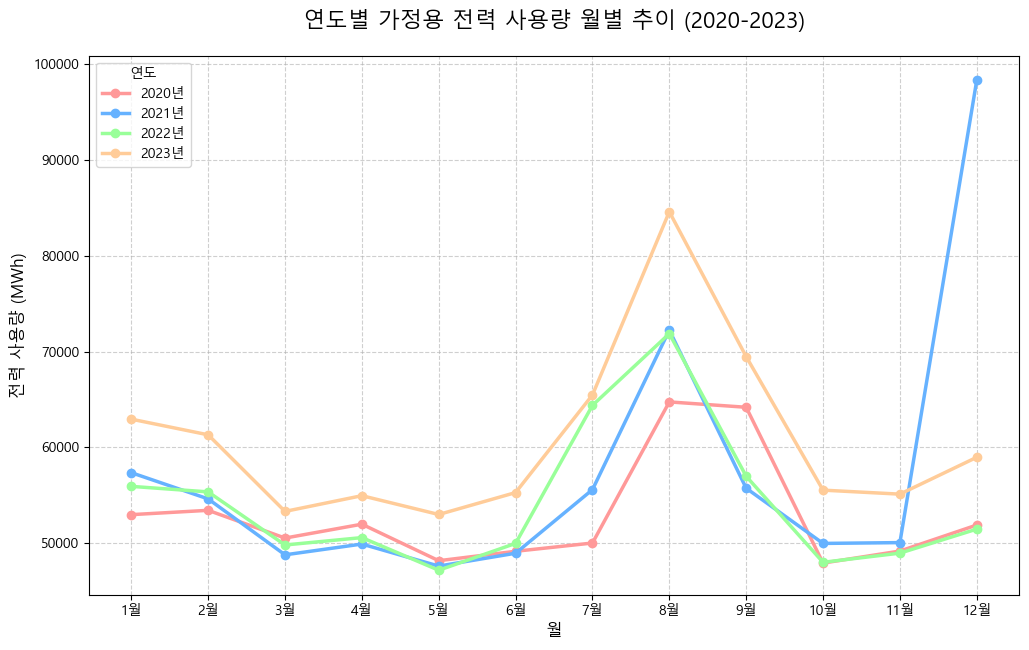

In [2]:
# 1. 데이터 불러오기
# (파일이 같은 폴더에 있다고 가정해. 이름이 다르면 수정해줘!)
df_home = pd.read_csv('home_data_2020_2023.csv')

# 2. '월' 데이터 정렬 (1월부터 12월까지 순서대로 나오게 하기)
df_home['월_숫자'] = df_home['월'].str.replace('월', '').astype(int)
df_home = df_home.sort_values('월_숫자')

# 3. 그래프 그리기
plt.figure(figsize=(12, 7))

# 연도별로 선을 하나씩 추가해요
years = ['2020년', '2021년', '2022년', '2023년']
# 색깔을 직접 정해주면 더 예뻐요!
colors = ['#ff9999', '#66b2ff', '#99ff99', '#ffcc99'] 

for i, year in enumerate(years):
    plt.plot(df_home['월'], df_home[year], 
             marker='o',          # 점 모양
             label=year,          # 이름표
             color=colors[i],     # 선 색깔
             linewidth=2.5)       # 선 두께

# 4. 그래프 예쁘게 꾸미기
plt.title('연도별 가정용 전력 사용량 월별 추이 (2020-2023)', fontsize=16, pad=20)
plt.xlabel('월', fontsize=12)
plt.ylabel('전력 사용량 (MWh)', fontsize=12)

# 범례(이름표) 표시
plt.legend(title='연도', loc='upper left')

# 격자 무늬 추가
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### 가정용 전력사용량과 평균 기온 비교

In [19]:
# 1. 데이터 불러오기
df_temp = pd.read_csv('dec_avg_temp_2020_2023.csv',  header=[0,1,2])
df_temp

,항목,2020,2021,2022,2023
,항목,기온,기온,기온,기온
,항목,평균,평균,평균,평균
0,12월,3.3,4.7,1.9,5.0


In [18]:
import pandas as pd

# 1. 데이터 불러오기
df_temp = pd.read_csv('dec_avg_temp_2020_2023.csv')

# 2. 0, 1, 2행(인덱스 기준) 제거하고 3행부터 끝까지 남기기
# .iloc[3:] 는 3번 인덱스(4번째 줄)부터 모든 데이터를 가져오라는 뜻입니다.
df_temp = df_temp.iloc[2:].copy()

# 3. '항목' 컬럼(열) 제거
if '항목' in df_temp.columns:
    df_temp = df_temp.drop(columns=['항목'])

# 4. 인덱스 초기화 (0부터 다시 시작하게 만듦)
df_temp = df_temp.reset_index(drop=True)

# 결과 확인
df_temp

,2020,2021,2022,2023
0,3.3,4.7,1.9,5.0


In [7]:
df_usage = pd.read_csv('dec_home_usage.csv')
df_usage

,month_name,year_2020,year_2021,year_2022,year_2023
0,12월,51872,98337,51447,58949


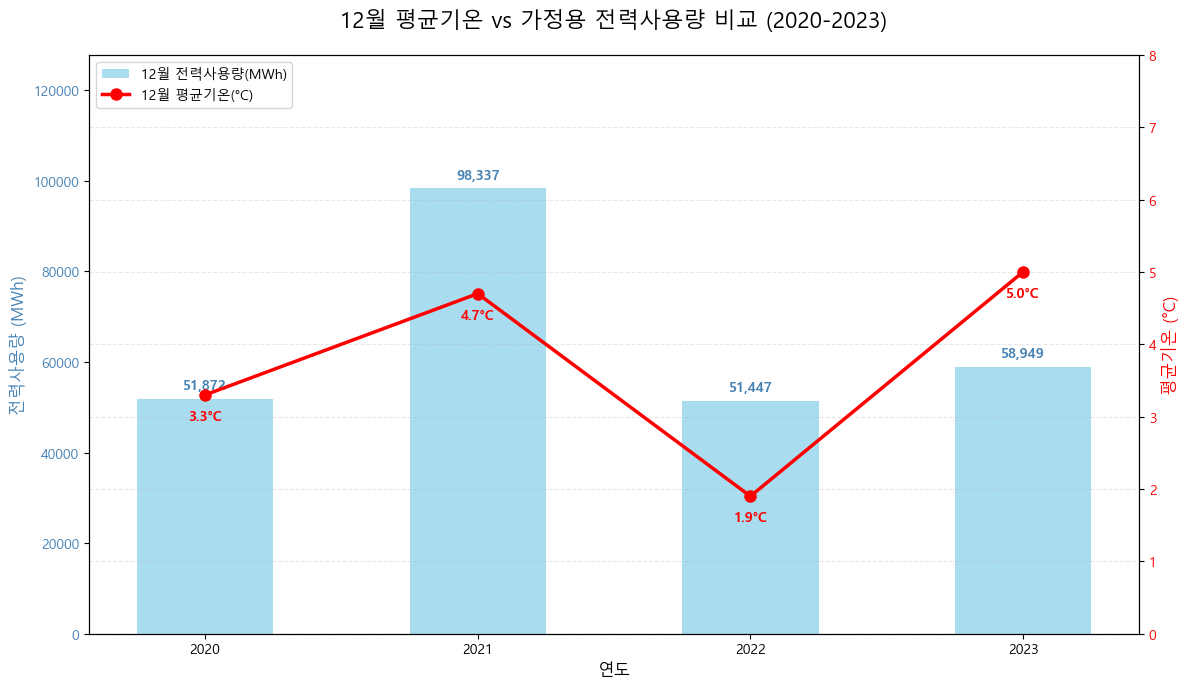

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 시각화 설정 (한글 폰트)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 준비 (정리된 데이터프레임을 가정)
# 앞에서 정리한 df_temp와 df_usage를 그대로 사용합니다.
years = ['2020', '2021', '2022', '2023']

# 기온 데이터 (df_temp의 첫 번째 행 수치)
temp_values = [3.3, 4.7, 1.9, 5.0]  # df_temp.iloc[0].values

# 전력 사용량 데이터 (df_usage의 12월 행 수치)
usage_values = [51872, 98337, 51447, 58949]  # df_usage.iloc[0, 1:5].values

# 3. 그래프 그리기
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- 막대 그래프: 12월 전력사용량 (왼쪽 Y축) ---
bars = ax1.bar(years, usage_values, color='skyblue', alpha=0.7, label='12월 전력사용량(MWh)', width=0.5, zorder=2)
ax1.set_xlabel('연도', fontsize=12)
ax1.set_ylabel('전력사용량 (MWh)', color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(0, max(usage_values) * 1.3) # 상단 수치 표시를 위한 여백

# 막대 위에 수치 표시
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1500,
             f'{int(height):,}', ha='center', va='bottom', color='steelblue', fontweight='bold')

# --- 꺾은선 그래프: 평균 기온 (오른쪽 Y축) ---
ax2 = ax1.twinx() # X축 공유
line = ax2.plot(years, temp_values, color='red', marker='o', markersize=8, 
                linewidth=2.5, label='12월 평균기온(°C)', zorder=3)
ax2.set_ylabel('평균기온 (°C)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, max(temp_values) + 3) # 기온 변화가 잘 보이게 범위 조정

# 꺾은선 위에 수치 표시
for i, txt in enumerate(temp_values):
    ax2.annotate(f'{txt}°C', (years[i], temp_values[i]), 
                 textcoords="offset points", xytext=(0, -18), ha='center', 
                 color='red', fontweight='bold')

# 4. 마무리 및 범례 정리
plt.title('12월 평균기온 vs 가정용 전력사용량 비교 (2020-2023)', fontsize=16, pad=20)

# 두 그래프의 범례를 합쳐서 하나로 표시
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
import pandas as pd

# 1. 데이터 불러오기
df_temp = pd.read_csv('aug_avg_temp_2020_2023.csv')

# 2. 0, 1, 2행(인덱스 기준) 제거하고 3행부터 끝까지 남기기
# .iloc[3:] 는 3번 인덱스(4번째 줄)부터 모든 데이터를 가져오라는 뜻입니다.
df_temp = df_temp.iloc[2:].copy()

# 3. '항목' 컬럼(열) 제거
if '항목' in df_temp.columns:
    df_temp = df_temp.drop(columns=['항목'])

# 4. 인덱스 초기화 (0부터 다시 시작하게 만듦)
df_temp = df_temp.reset_index(drop=True)

# 결과 확인
df_temp

,2020,2021,2022,2023
0,28.6,25.9,26.9,27.0


In [23]:
df_usage = pd.read_csv('aug_home_usage.csv')
df_usage

,month_name,year_2020,year_2021,year_2022,year_2023
0,8월,64734,72233,71864,84598


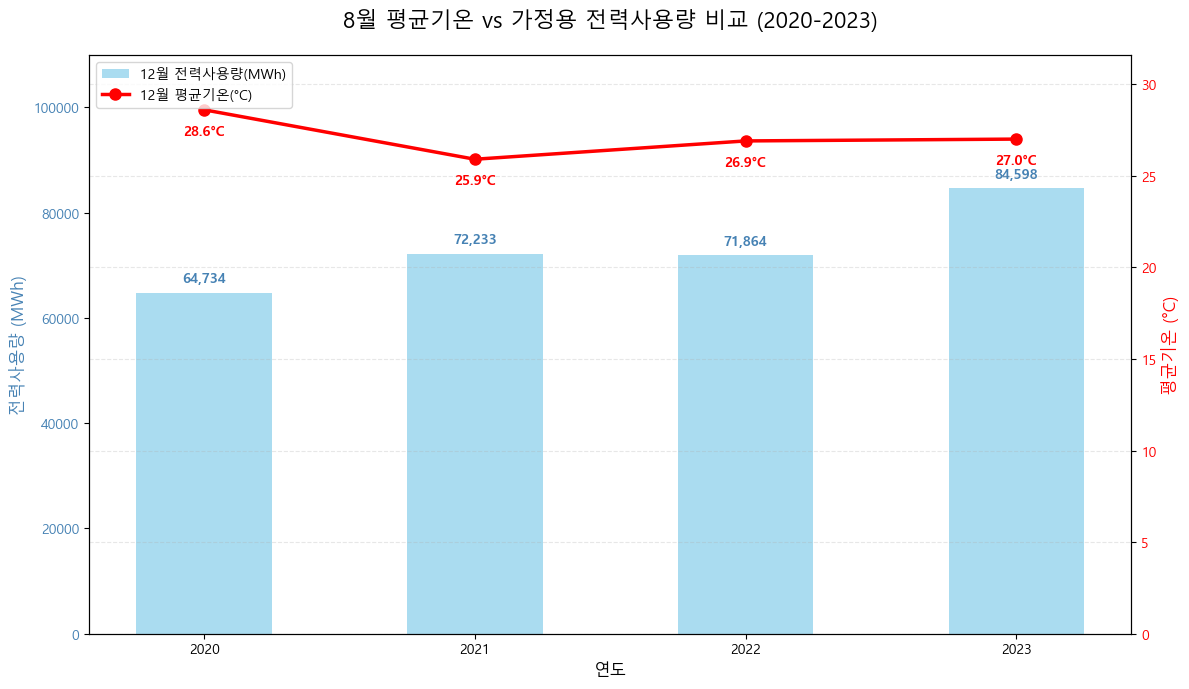

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 시각화 설정 (한글 폰트)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 준비 (정리된 데이터프레임을 가정)
# 앞에서 정리한 df_temp와 df_usage를 그대로 사용합니다.
years = ['2020', '2021', '2022', '2023']

# 기온 데이터 (df_temp의 첫 번째 행 수치)
temp_values = [28.6, 25.9, 26.9, 27.0]  # df_temp.iloc[0].values

# 전력 사용량 데이터 (df_usage의 12월 행 수치)
usage_values = [64734, 72233, 71864, 84598]  # df_usage.iloc[0, 1:5].values

# 3. 그래프 그리기
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- 막대 그래프: 12월 전력사용량 (왼쪽 Y축) ---
bars = ax1.bar(years, usage_values, color='skyblue', alpha=0.7, label='12월 전력사용량(MWh)', width=0.5, zorder=2)
ax1.set_xlabel('연도', fontsize=12)
ax1.set_ylabel('전력사용량 (MWh)', color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(0, max(usage_values) * 1.3) # 상단 수치 표시를 위한 여백

# 막대 위에 수치 표시
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1500,
             f'{int(height):,}', ha='center', va='bottom', color='steelblue', fontweight='bold')

# --- 꺾은선 그래프: 평균 기온 (오른쪽 Y축) ---
ax2 = ax1.twinx() # X축 공유
line = ax2.plot(years, temp_values, color='red', marker='o', markersize=8, 
                linewidth=2.5, label='12월 평균기온(°C)', zorder=3)
ax2.set_ylabel('평균기온 (°C)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, max(temp_values) + 3) # 기온 변화가 잘 보이게 범위 조정

# 꺾은선 위에 수치 표시
for i, txt in enumerate(temp_values):
    ax2.annotate(f'{txt}°C', (years[i], temp_values[i]), 
                 textcoords="offset points", xytext=(0, -18), ha='center', 
                 color='red', fontweight='bold')

# 4. 마무리 및 범례 정리
plt.title('8월 평균기온 vs 가정용 전력사용량 비교 (2020-2023)', fontsize=16, pad=20)

# 두 그래프의 범례를 합쳐서 하나로 표시
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#### 산업용

##### 제조업

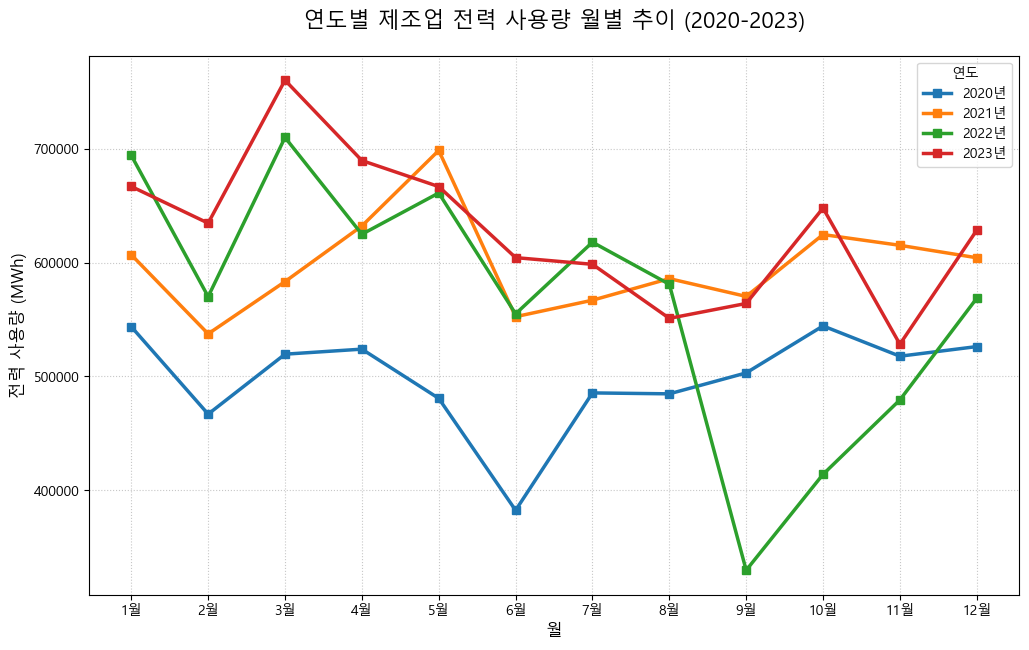

In [3]:
# 1. 제조업 데이터 불러오기
df_mfg = pd.read_csv('data1_2020_2023.csv')

# 2. '월' 데이터 정렬 (1월~12월 순서 맞추기)
df_mfg['월_숫자'] = df_mfg['월'].str.replace('월', '').astype(int)
df_mfg = df_mfg.sort_values('월_숫자')

# 3. 그래프 그리기
plt.figure(figsize=(12, 7))

# 연도별 이름과 선 색상 설정
years = ['2020년', '2021년', '2022년', '2023년']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # 대비가 명확한 색상들

for i, year in enumerate(years):
    plt.plot(df_mfg['월'], df_mfg[year], 
             marker='s',          # 제조업은 사각형(square) 점으로 표시해볼까요?
             label=year, 
             color=colors[i], 
             linewidth=2.5)

# 4. 그래프 꾸미기
plt.title('연도별 제조업 전력 사용량 월별 추이 (2020-2023)', fontsize=16, pad=20)
plt.xlabel('월', fontsize=12)
plt.ylabel('전력 사용량 (MWh)', fontsize=12)

plt.legend(title='연도', loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

##### 광업

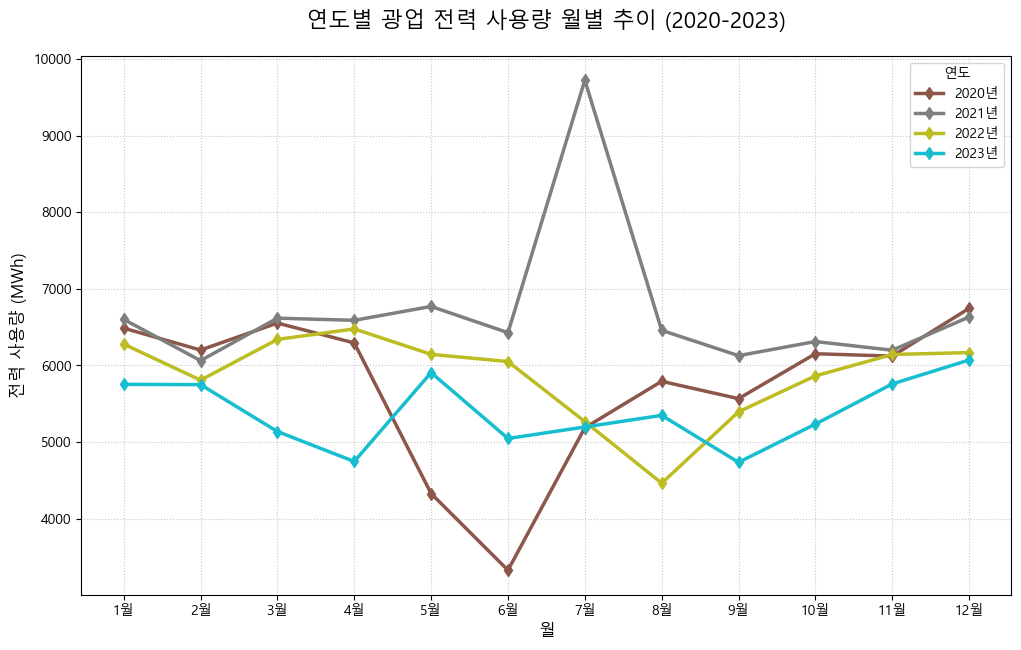

In [6]:
# 1. 광업 데이터 불러오기
df_mining = pd.read_csv('data2_2020_2023.csv')

# 2. '월' 데이터 정렬 (1월~12월 순서 맞추기)
df_mining['월_숫자'] = df_mining['월'].str.replace('월', '').astype(int)
df_mining = df_mining.sort_values('월_숫자')

# 3. 그래프 그리기
plt.figure(figsize=(12, 7))

# 연도별 이름과 선 색상 설정 (광업은 돌이나 땅의 느낌인 갈색/회색 계열을 섞어볼게!)
years = ['2020년', '2021년', '2022년', '2023년']
colors = ['#8c564b', '#7f7f7f', '#bcbd22', '#17becf'] 

for i, year in enumerate(years):
    plt.plot(df_mining['월'], df_mining[year], 
             marker='d',          # 광업은 다이아몬드(diamond) 점으로 표시!
             label=year, 
             color=colors[i], 
             linewidth=2.5)

# 4. 그래프 꾸미기
plt.title('연도별 광업 전력 사용량 월별 추이 (2020-2023)', fontsize=16, pad=20)
plt.xlabel('월', fontsize=12)
plt.ylabel('전력 사용량 (MWh)', fontsize=12)

plt.legend(title='연도', loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

##### 농림수산업

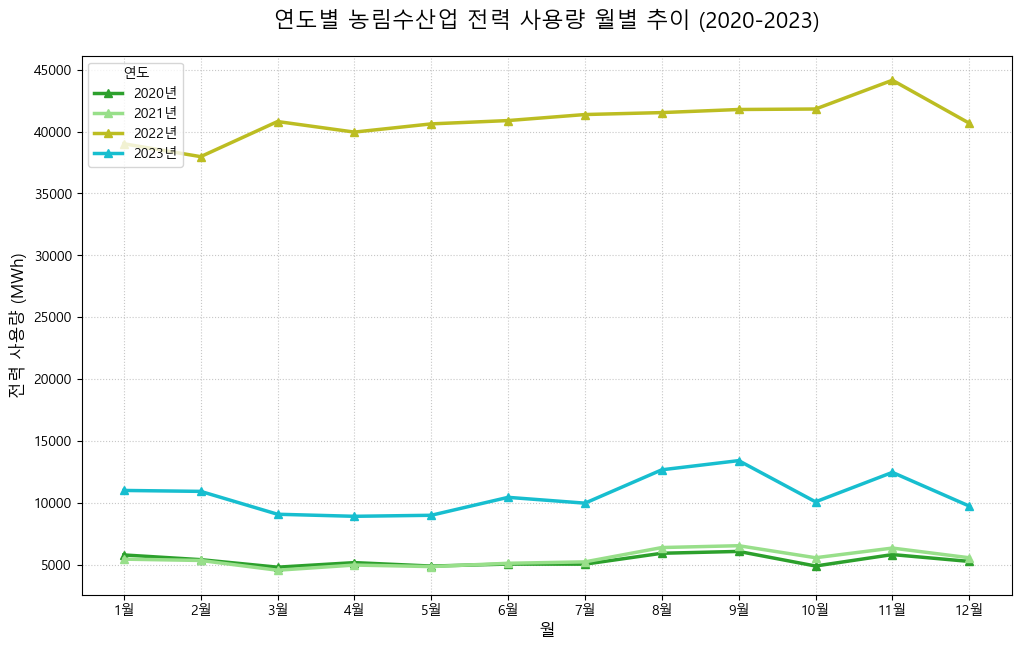

In [7]:
# 1. 농림수산업 데이터 불러오기
df_agri = pd.read_csv('data3_2020_2023.csv')

# 2. '월' 데이터 정렬 (1월~12월 순서 맞추기)
df_agri['월_숫자'] = df_agri['월'].str.replace('월', '').astype(int)
df_agri = df_agri.sort_values('월_숫자')

# 3. 그래프 그리기
plt.figure(figsize=(12, 7))

# 연도별 이름과 선 색상 설정 (농림수산업은 싱그러운 초록색과 연두색 계열!)
years = ['2020년', '2021년', '2022년', '2023년']
colors = ['#2ca02c', '#98df8a', '#bcbd22', '#17becf'] 

for i, year in enumerate(years):
    plt.plot(df_agri['월'], df_agri[year], 
             marker='^',          # 농림수산업은 산 모양을 닮은 세모(^)!
             label=year, 
             color=colors[i], 
             linewidth=2.5)

# 4. 그래프 꾸미기
plt.title('연도별 농림수산업 전력 사용량 월별 추이 (2020-2023)', fontsize=16, pad=20)
plt.xlabel('월', fontsize=12)
plt.ylabel('전력 사용량 (MWh)', fontsize=12)

plt.legend(title='연도', loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()